In [1]:
import pandas as pd

In [2]:
import transformers

In [3]:
import torch
import os

In [6]:
MODEL = "OLMo-2-0425-1B_tulu-v2-sft-mixture"

In [19]:
indices_dir = os.path.join("./models", MODEL, "indices")
indices = [
    (*f.split("_")[:-1], torch.load(os.path.join(indices_dir, f)))
    for f in os.listdir(indices_dir)
    if os.path.isfile(os.path.join(indices_dir, f)) and f.endswith((".pt"))
]
indices = [(int(i.replace("iter","")),t, [int(j) for j in ind]) for i,t, ind in indices]
df = pd.DataFrame(indices, columns=["interation", "subset", "indices"])
df

,interation,subset,indices
0,154,full,"[218, 185, 164, 68, 53, 217, 188, 258]"
1,194,full,"[252, 275, 267, 111, 33, 97, 150, 266]"
2,80,selected,"[296, 130, 361, 87]"
3,128,sampling,"[279, 46, 114, 69, 8, 347, 161, 34]"
4,164,sampling,"[49, 236, 321, 103, 232, 376, 92, 306]"
...,...,...,...
595,44,sampling,"[220, 197, 204, 316, 99, 88, 185, 122]"
596,43,sampling,"[23, 113, 70, 393, 71, 338, 22, 340]"
597,94,selected,"[252, 97, 150, 266]"
598,32,full,"[149, 363, 63, 16, 325, 347, 270, 201]"


In [22]:
import pandas as pd

grouped = df.groupby('interation')


results = []

for iteration, group in grouped:
    sampling = group[group['subset'] == 'sampling']['indices']
    full = group[group['subset'] == 'full']['indices']
    selected = group[group['subset'] == 'selected']['indices']
    
    sampling_set = set(sampling.iloc[0]) if not sampling.empty else set()
    full_set = set(full.iloc[0]) if not full.empty else set()
    selected_set = set(selected.iloc[0]) if not selected.empty else set()

    selected_in_sampling = selected_set.issubset(sampling_set) if selected_set else None
    sampling_in_full = sampling_set.issubset(full_set) if sampling_set else None
    selected_in_full = selected_set.issubset(full_set) if selected_set else None
    results.append({
        'interation': iteration,
        'selected_in_sampling': selected_in_sampling,
        'sampling_in_full': sampling_in_full,
        'selected_in_full':selected_in_full
    })


results_df = pd.DataFrame(results)
print(results_df)
assert all(results_df["selected_in_full"])
assert all(results_df["sampling_in_full"])
# assert not all(results_df["selected_in_sampling"])

     interation  selected_in_sampling  sampling_in_full  selected_in_full
0             0                  True              True              True
1             1                  True              True              True
2             2                  True              True              True
3             3                  True              True              True
4             4                  True              True              True
..          ...                   ...               ...               ...
195         195                  True              True              True
196         196                  True              True              True
197         197                  True              True              True
198         198                  True              True              True
199         199                  True              True              True

[200 rows x 4 columns]


In [23]:
df["indices_len"] = df["indices"].apply(lambda x: len(x))

In [24]:
df.groupby("subset")["indices_len"].describe()

,count,mean,std,min,25%,50%,75%,max
subset,,,,,,,,
full,200.0,8.0,0.0,8.0,8.0,8.0,8.0,8.0
sampling,200.0,8.0,0.0,8.0,8.0,8.0,8.0,8.0
selected,200.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0


subset
full        Axes(0.125,0.11;0.775x0.77)
sampling    Axes(0.125,0.11;0.775x0.77)
selected    Axes(0.125,0.11;0.775x0.77)
Name: indices_len, dtype: object

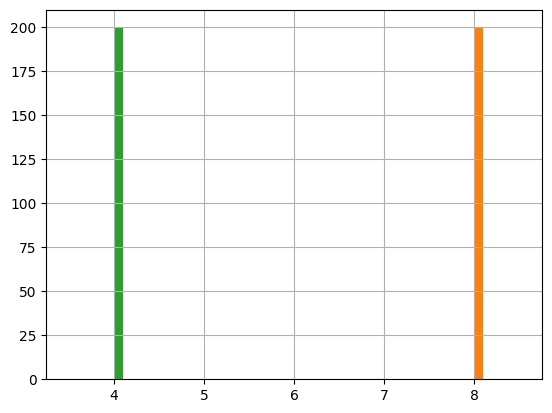

In [25]:
df.groupby("subset")["indices_len"].hist()

In [30]:
test_inputs_tuple

(tensor([[  101,  1045,  2293, 16596,  1011, 10882,  1998,  2572,  5627,  2000,
           2404,  2039,  2007,  1037,  2843,  1012, 16596,  1011, 10882,  5691,
           1013,  2694,  2024,  2788,  2104, 11263, 25848,  1010,  2104,  1011,
          12315,  1998, 28947,  1012,  1045,  2699,  2000,  2066,  2023,  1010,
           1045,  2428,  2106,  1010,  2021,  2009,  2003,  2000,  2204,  2694,
          16596,  1011, 10882,  2004, 17690,  1019,  2003,  2000,  2732, 10313,
           1006,  1996,  2434,  1007,  1012, 10021,  4013,  3367, 20086,  2015,
           1010, 10036, 19747,  4520,  1010, 25931,  3064, 22580,  1010,  1039,
           2290,  2008,  2987,  1005,  1056,  2674,  1996,  4281,  1010,  1998,
          16267,  2028,  1011,  8789,  3494,  3685,  2022,  9462,  2007,  1037,
           1005, 16596,  1011, 10882,  1005,  4292,  1012,  1006,  1045,  1005,
           1049,  2469,  2045,  2024,  2216,  1997,  2017,  2041,  2045,  2040,
           2228, 17690,  1019,  2003,  2

TypeError: The inputs given to jacobian must be either a Tensor or a tuple of Tensors but the given inputs has type <class 'transformers.modeling_outputs.CausalLMOutputWithPast'>.